# Predictive Analytics: Final Neural-Network Training and Test Evaluation

This notebook reads the winning Census-Tract configuration from the two-stage grid search and makes a full retraining. Here we evaluate the first time on the Test set.

Besides the grid search was performed only on census_tract_1h we use this model to train and evaluate the other datasets (time spatial units). Of course a separate grid search for each dataset would have most likely led to different model and training setting for each dataset.

In [1]:
from dataclasses import dataclass
import gc
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from helper_functions import (
    collect_predictions,
    compute_regression_metrics,
    get_torch_device,
    load_model_from_checkpoint,
)
from run_config import MODELS_DIR, PATHS, RUN_MODE, demand_split_paths

## Final-training configuration

Only the epoch budget and patience change relative to the grid-search winner. Architecture, learning rate, imbalance strategy, batch size, output activation, spatial encoding, and Balanced-MAE definition are transferred unchanged.

In [ ]:
if RUN_MODE != "full":
    raise RuntimeError("Final NN training is intentionally restricted to RUN_MODE='full'.")

ALL_DATASET_CONFIGS = (
    {"spatial_unit": "census_tracts", "spatial_col": "census_tract", "time_unit": "1h"},
    {"spatial_unit": "hexagon", "spatial_col": "h3_cell", "time_unit": "1h", "h3_resolution": 7},
    {"spatial_unit": "community_areas", "spatial_col": "community_area", "time_unit": "1h"},
    {"spatial_unit": "community_areas_unfiltered", "spatial_col": "community_area", "time_unit": "1h"},
    {"spatial_unit": "census_tracts", "spatial_col": "census_tract", "time_unit": "4h"},
    {"spatial_unit": "hexagon", "spatial_col": "h3_cell", "time_unit": "4h", "h3_resolution": 7},
    {"spatial_unit": "community_areas", "spatial_col": "community_area", "time_unit": "4h"},
    {"spatial_unit": "community_areas_unfiltered", "spatial_col": "community_area", "time_unit": "4h"},
    {"spatial_unit": "census_tracts", "spatial_col": "census_tract", "time_unit": "24h"},
    {"spatial_unit": "hexagon", "spatial_col": "h3_cell", "time_unit": "24h", "h3_resolution": 7},
    {"spatial_unit": "community_areas", "spatial_col": "community_area", "time_unit": "24h"},
    {"spatial_unit": "community_areas_unfiltered", "spatial_col": "community_area", "time_unit": "24h"},
)

# This tuple controls which models are trained when the training cell is executed and may contain any subset of ALL_DATASET_CONFIGS
DATASET_CONFIGS = ALL_DATASET_CONFIGS

TARGET_COL = "trip_count"
TIME_COL = "datetime_hour"
MODEL_VERSION = "final_nn_v1"
GRID_SEARCH_WINNER_PATH = (
    MODELS_DIR / "nn_grid_search" / "grid_search_v1_selected_models.parquet"
)
OUTPUT_DIR = MODELS_DIR / "nn_final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_PREDICTION_DIR = PATHS.train_test_dir / "baseline_predictions"

MAX_EPOCHS = 100
PATIENCE = 10
MIN_DELTA = 0.0
BASE_SEED = 42
BATCH_SIZE = 1024
DEMAND_THRESHOLD = 0.5
SKILL_SCORE_REFERENCE = "spatial_time_weekday_mean"

EXCLUDE_COLS = {
    TARGET_COL, TIME_COL, "date", "_split_bucket",
    "month", "weekday", "hour",
    "weather_qc_corrected", "station_observed", "weather_imputed", "precipitation_missing",
    "trip_seconds_sum", "trip_seconds_mean", "trip_seconds_min", "trip_seconds_max",
    "trip_miles_sum", "trip_miles_mean", "trip_miles_min", "trip_miles_max",
    "fare_sum", "fare_mean", "fare_min", "fare_max",
    "tips_sum", "tips_mean", "tips_min", "tips_max",
    "tolls_sum", "tolls_mean", "tolls_min", "tolls_max",
    "extras_sum", "extras_mean", "extras_min", "extras_max",
    "trip_total_sum", "trip_total_mean", "trip_total_min", "trip_total_max",
    "most_common_payment_type",
}

BASELINE_PREDICTION_COLS = {
    "zero": "prediction_zero",
    "global_median": "prediction_global_median",
    "spatial_time_weekday_mean": "prediction_spatial_time_weekday_mean",
}


def split_paths_for(config):
    spatial_unit = config["spatial_unit"]
    time_unit = config["time_unit"]
    if spatial_unit == "hexagon":
        return demand_split_paths(
            spatial_unit, time_unit, h3_resolution=config["h3_resolution"]
        )
    if spatial_unit == "community_areas_unfiltered":
        gold_path = getattr(
            PATHS, f"gold_{time_unit}_demand_community_area_unfiltered"
        )
        return {
            split: PATHS.train_test_dir / f"{gold_path.stem}_{split.upper()}.parquet"
            for split in ("train", "val", "test")
        }
    return demand_split_paths(spatial_unit, time_unit)


def model_tag_for(config):
    if config["spatial_unit"] == "hexagon":
        return f"hexagon_h3r{config['h3_resolution']}_{config['time_unit']}"
    return f"{config['spatial_unit']}_{config['time_unit']}"

## Load and freeze the grid-search winner

The configuration is read instead of manually copied and must contain exactly one selected `census_tracts_1h` model.

In [3]:
if not GRID_SEARCH_WINNER_PATH.exists():
    raise FileNotFoundError(
        f"Missing grid-search winner: {GRID_SEARCH_WINNER_PATH}. "
        "Run 03_02_predictive_analytics_nn_grid_search.ipynb first."
    )

winner_df = pl.read_parquet(GRID_SEARCH_WINNER_PATH)
if winner_df.height != 1:
    raise ValueError(f"Expected one grid-search winner, found {winner_df.height}")
winner = winner_df.row(0, named=True)
if winner["model_tag"] != "census_tracts_1h":
    raise ValueError(f"Expected census_tracts_1h winner, found {winner['model_tag']}")

WINNING_CONFIG = {
    "strategy": winner["strategy"],
    "positive_weight": winner["positive_weight"],
    "zero_to_positive_ratio": winner["zero_to_positive_ratio"],
    "hidden_dims": tuple(int(value) for value in winner["hidden_dims"].split("-")),
    "learning_rate": float(winner["learning_rate"]),
    "balanced_mae_alpha": float(winner["balanced_mae_alpha"]),
}
if WINNING_CONFIG["strategy"] not in {"standard", "weighted_loss", "zero_undersampling"}:
    raise ValueError(f"Unsupported winning strategy: {WINNING_CONFIG['strategy']}")
if WINNING_CONFIG["strategy"] == "weighted_loss" and WINNING_CONFIG["positive_weight"] is None:
    raise ValueError("Weighted-loss winner is missing positive_weight")
if (
    WINNING_CONFIG["strategy"] == "zero_undersampling"
    and WINNING_CONFIG["zero_to_positive_ratio"] is None
):
    raise ValueError("Undersampling winner is missing zero_to_positive_ratio")

selected_config_path = OUTPUT_DIR / f"{MODEL_VERSION}_selected_configuration.parquet"
winner_df.write_parquet(selected_config_path)
print("Winning configuration:", WINNING_CONFIG)
print(f"Saved selected configuration to {selected_config_path}")

Winning configuration: {'strategy': 'weighted_loss', 'positive_weight': 5.0, 'zero_to_positive_ratio': None, 'hidden_dims': (128, 64), 'learning_rate': 0.001, 'balanced_mae_alpha': 0.5}
Saved selected configuration to /Users/lennartjekel/dev/git/Group-3-AAA/models/full/nn_final/final_nn_v1_selected_configuration.parquet


## Winning model architecture

The architecture is reconstructed from the winning hidden-layer widths.

In [4]:
class TaxiDemandFinalNN(nn.Module):
    def __init__(self, input_dim, num_spatial_units, hidden_dims):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend((nn.Linear(previous_dim, hidden_dim), nn.ReLU()))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)
        self.spatial_bias = nn.Embedding(
            num_embeddings=num_spatial_units + 1,
            embedding_dim=1,
            padding_idx=0,
        )
        nn.init.zeros_(self.spatial_bias.weight)
        self.output_activation = nn.Softplus()

    def forward(self, x, spatial_idx):
        return self.output_activation(self.network(x) + self.spatial_bias(spatial_idx))

## Preparation and training utilities

The Scaler and spatial vocabulary are fitted on train only. Val remains complete and determines the best checkpoint through Balanced MAE.

In [5]:
@dataclass
class PreparedDataset:
    config: dict
    model_tag: str
    spatial_col: str
    feature_cols: list[str]
    spatial_to_idx: dict[str, int]
    scaler: StandardScaler
    train_X: torch.Tensor
    train_spatial: torch.Tensor
    train_y: torch.Tensor
    val_loader: DataLoader


def set_reproducible_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)


def validate_model_frame(frame, feature_cols, spatial_col, split_name):
    required = {*feature_cols, spatial_col, TARGET_COL}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{split_name} is missing columns: {sorted(missing)}")
    if frame.is_empty():
        raise ValueError(f"{split_name} split is empty")
    selected = frame.select([*feature_cols, TARGET_COL])
    null_counts = selected.null_count().row(0, named=True)
    columns_with_nulls = [name for name, count in null_counts.items() if count]
    if columns_with_nulls:
        raise ValueError(f"{split_name} contains nulls in: {columns_with_nulls}")
    values = selected.to_numpy()
    if not np.issubdtype(values.dtype, np.number):
        raise TypeError(f"{split_name} model features and target must be numeric")
    if not np.isfinite(values).all():
        raise ValueError(f"{split_name} contains non-finite model values")


def encode_spatial(frame, spatial_col, spatial_to_idx):
    return (
        frame.select(
            pl.col(spatial_col).cast(pl.String)
            .replace_strict(spatial_to_idx, default=0)
            .cast(pl.Int64).alias("spatial_idx")
        ).to_series().to_numpy()
    )


def prepare_dataset(config):
    paths = split_paths_for(config)
    train_df = pl.read_parquet(paths["train"])
    val_df = pl.read_parquet(paths["val"])
    spatial_col = config["spatial_col"]
    feature_cols = [
        col for col in train_df.columns
        if col not in EXCLUDE_COLS and col != spatial_col
    ]
    validate_model_frame(train_df, feature_cols, spatial_col, "train")
    validate_model_frame(val_df, feature_cols, spatial_col, "validation")
    if train_df.select(feature_cols).schema != val_df.select(feature_cols).schema:
        raise TypeError("Train and validation feature schemas differ")

    spatial_values = sorted(
        train_df.select(pl.col(spatial_col).cast(pl.String)).to_series().unique().to_list()
    )
    spatial_to_idx = {value: index + 1 for index, value in enumerate(spatial_values)}
    scaler = StandardScaler().fit(train_df.select(feature_cols).to_numpy())
    train_X = torch.tensor(
        scaler.transform(train_df.select(feature_cols).to_numpy()).astype("float32")
    )
    train_spatial = torch.tensor(
        encode_spatial(train_df, spatial_col, spatial_to_idx), dtype=torch.long
    )
    train_y = torch.tensor(train_df.select(TARGET_COL).to_numpy().astype("float32"))
    val_X = torch.tensor(
        scaler.transform(val_df.select(feature_cols).to_numpy()).astype("float32")
    )
    val_spatial = torch.tensor(
        encode_spatial(val_df, spatial_col, spatial_to_idx), dtype=torch.long
    )
    val_y = torch.tensor(val_df.select(TARGET_COL).to_numpy().astype("float32"))
    val_loader = DataLoader(
        TensorDataset(val_X, val_spatial, val_y), batch_size=BATCH_SIZE, shuffle=False
    )
    print(
        f"Prepared {model_tag_for(config)}: train={train_df.height:,}, val={val_df.height:,}, "
        f"train zero share={(train_y == 0).float().mean().item():.3f}"
    )
    return PreparedDataset(
        config=dict(config), model_tag=model_tag_for(config), spatial_col=spatial_col,
        feature_cols=feature_cols, spatial_to_idx=spatial_to_idx, scaler=scaler,
        train_X=train_X, train_spatial=train_spatial, train_y=train_y,
        val_loader=val_loader,
    )

In [6]:
def make_train_loader(prepared, seed):
    strategy = WINNING_CONFIG["strategy"]
    if strategy == "zero_undersampling":
        y_flat = prepared.train_y.reshape(-1)
        positive_indices = torch.where(y_flat > 0)[0]
        zero_indices = torch.where(y_flat == 0)[0]
        requested_zeros = int(
            WINNING_CONFIG["zero_to_positive_ratio"] * positive_indices.numel()
        )
        sampled_zero_count = min(requested_zeros, zero_indices.numel())
        sample_generator = torch.Generator().manual_seed(seed)
        sampled_zeros = zero_indices[
            torch.randperm(zero_indices.numel(), generator=sample_generator)[:sampled_zero_count]
        ]
        indices = torch.cat((positive_indices, sampled_zeros))
        X = prepared.train_X[indices]
        spatial = prepared.train_spatial[indices]
        y = prepared.train_y[indices]
    else:
        X, spatial, y = prepared.train_X, prepared.train_spatial, prepared.train_y
    shuffle_generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        TensorDataset(X, spatial, y), batch_size=BATCH_SIZE, shuffle=True,
        generator=shuffle_generator,
    ), len(y)


def compute_training_loss(y_pred, y_true):
    squared_error = (y_pred - y_true) ** 2
    if WINNING_CONFIG["strategy"] == "weighted_loss":
        weights = torch.where(
            y_true > 0, WINNING_CONFIG["positive_weight"], 1.0
        )
        return (weights * squared_error).sum() / weights.sum()
    return squared_error.mean()


def train_one_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for X_batch, spatial_batch, y_batch in train_loader:
        X_batch, spatial_batch, y_batch = X_batch.to(device), spatial_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = compute_training_loss(model(X_batch, spatial_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        total_samples += X_batch.size(0)
    return total_loss / total_samples


def evaluate_epoch(model, data_loader, device):
    model.eval()
    absolute_error = squared_error = 0.0
    zero_absolute_error = nonzero_absolute_error = 0.0
    total_samples = zero_samples = nonzero_samples = 0
    with torch.inference_mode():
        for X_batch, spatial_batch, y_batch in data_loader:
            X_batch, spatial_batch, y_batch = X_batch.to(device), spatial_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch, spatial_batch)
            batch_absolute_error = torch.abs(y_pred - y_batch)
            zero_mask = y_batch <= 0
            nonzero_mask = ~zero_mask
            absolute_error += batch_absolute_error.sum().item()
            squared_error += ((y_pred - y_batch) ** 2).sum().item()
            zero_absolute_error += batch_absolute_error[zero_mask].sum().item()
            nonzero_absolute_error += batch_absolute_error[nonzero_mask].sum().item()
            total_samples += X_batch.size(0)
            zero_samples += zero_mask.sum().item()
            nonzero_samples += nonzero_mask.sum().item()
    if zero_samples == 0 or nonzero_samples == 0:
        raise ValueError("Balanced MAE requires zero and non-zero validation targets")
    zero_mae = zero_absolute_error / zero_samples
    nonzero_mae = nonzero_absolute_error / nonzero_samples
    alpha = WINNING_CONFIG["balanced_mae_alpha"]
    return {
        "val_mae": absolute_error / total_samples,
        "val_mse": squared_error / total_samples,
        "val_rmse": math.sqrt(squared_error / total_samples),
        "val_zero_mae": zero_mae,
        "val_nonzero_mae": nonzero_mae,
        "val_balanced_mae": (1.0 - alpha) * zero_mae + alpha * nonzero_mae,
    }

## Final training

Every dataset is trained from scratch for at most 100 epochs with Patience 10. Each best Validation Balanced-MAE checkpoint and complete history is saved before TEST is accessed.

In [8]:
device = get_torch_device()
print("Using device:", device)


def train_final_model(prepared, seed):
    set_reproducible_seed(seed)
    train_loader, sampled_train_rows = make_train_loader(prepared, seed)
    model_kwargs = {
        "input_dim": len(prepared.feature_cols),
        "num_spatial_units": len(prepared.spatial_to_idx),
        "hidden_dims": WINNING_CONFIG["hidden_dims"],
    }
    model = TaxiDemandFinalNN(**model_kwargs).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=WINNING_CONFIG["learning_rate"]
    )
    checkpoint_path = OUTPUT_DIR / f"{MODEL_VERSION}_{prepared.model_tag}_best_model.pt"
    history_path = OUTPUT_DIR / f"{MODEL_VERSION}_{prepared.model_tag}_training_history.parquet"
    history = []
    best_balanced_mae = float("inf")
    epochs_without_improvement = 0

    print(f"\n=== Final training: {prepared.model_tag} | train rows={sampled_train_rows:,} ===")
    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val_metrics = evaluate_epoch(model, prepared.val_loader, device)
        epoch_result = {"epoch": epoch, "train_loss": train_loss, **val_metrics}
        if not all(math.isfinite(value) for value in epoch_result.values()):
            raise RuntimeError(f"Non-finite metric for {prepared.model_tag} at epoch {epoch}")
        history.append(epoch_result)

        checkpoint = {
            **epoch_result,
            "selection_metric": "val_balanced_mae",
            "model_version": MODEL_VERSION,
            "model_tag": prepared.model_tag,
            "dataset_config": dict(prepared.config),
            "winning_config": dict(WINNING_CONFIG),
            "seed": seed,
            "batch_size": BATCH_SIZE,
            "sampled_train_rows": sampled_train_rows,
            "feature_cols": prepared.feature_cols,
            "spatial_col": prepared.spatial_col,
            "spatial_to_idx": prepared.spatial_to_idx,
            "model_kwargs": model_kwargs,
            "scaler_mean": prepared.scaler.mean_.tolist(),
            "scaler_scale": prepared.scaler.scale_.tolist(),
            "scaler_var": prepared.scaler.var_.tolist(),
            "scaler_n_features_in": int(prepared.scaler.n_features_in_),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        }
        if val_metrics["val_balanced_mae"] < best_balanced_mae - MIN_DELTA:
            best_balanced_mae = val_metrics["val_balanced_mae"]
            epochs_without_improvement = 0
            torch.save(checkpoint, checkpoint_path)
        else:
            epochs_without_improvement += 1

        print(
            f"{prepared.model_tag} | {epoch:03d}/{MAX_EPOCHS} | "
            f"train objective={train_loss:.4f} | val MAE={val_metrics['val_mae']:.4f} | "
            f"balanced MAE={val_metrics['val_balanced_mae']:.4f} | "
            f"stale={epochs_without_improvement}/{PATIENCE}"
        )
        if epochs_without_improvement >= PATIENCE:
            break

    history_df = pl.DataFrame(history)
    history_df.write_parquet(history_path)
    return checkpoint_path, history_path, history_df

Using device: mps


## Final test evaluation

The best validation checkpoint is loaded before TEST is read. Stored test-baseline keys and targets must match the model test split exactly.

In [ ]:
def reconstruct_scaler(checkpoint):
    scaler = StandardScaler()
    scaler.mean_ = np.asarray(checkpoint["scaler_mean"], dtype=np.float64)
    scaler.scale_ = np.asarray(checkpoint["scaler_scale"], dtype=np.float64)
    scaler.var_ = np.asarray(checkpoint["scaler_var"], dtype=np.float64)
    scaler.n_features_in_ = checkpoint["scaler_n_features_in"]
    return scaler


def classification_metrics(predictions):
    y_true = predictions["y_true"].to_numpy()
    y_pred = predictions["y_pred"].to_numpy()
    actual_positive = y_true > 0
    predicted_positive = y_pred >= DEMAND_THRESHOLD
    true_positive = np.logical_and(actual_positive, predicted_positive).sum()
    predicted_count = predicted_positive.sum()
    actual_count = actual_positive.sum()
    return {
        "test_actual_positive_share": float(actual_positive.mean()),
        "test_predicted_positive_share": float(predicted_positive.mean()),
        "test_demand_precision": (
            float(true_positive / predicted_count) if predicted_count else float("nan")
        ),
        "test_demand_recall": (
            float(true_positive / actual_count) if actual_count else float("nan")
        ),
    }


def load_and_validate_test_baselines(test_df, spatial_col, model_tag):
    path = BASELINE_PREDICTION_DIR / f"{model_tag}_test_baselines.parquet"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing test baselines: {path}. Run the trivial-baseline notebook first."
        )
    predictions = pl.read_parquet(path)
    required = {TIME_COL, spatial_col, "y_true", *BASELINE_PREDICTION_COLS.values()}
    missing = required.difference(predictions.columns)
    if missing:
        raise ValueError(f"Test baseline file is missing columns: {sorted(missing)}")
    if predictions.height != test_df.height:
        raise ValueError("Baseline and model test row counts differ")
    key_cols = [TIME_COL, spatial_col]
    if predictions.select(key_cols).unique().height != predictions.height:
        raise ValueError(f"Test baseline file contains duplicate keys: {path}")
    expected = test_df.select(
        *key_cols, pl.col(TARGET_COL).cast(pl.Float64).alias("expected_y_true")
    )
    aligned = expected.join(
        predictions.select(*key_cols, "y_true"), on=key_cols, how="left"
    )
    if aligned["y_true"].null_count():
        raise ValueError("Test baseline file does not contain every model test key")
    max_difference = aligned.select(
        (pl.col("expected_y_true") - pl.col("y_true")).abs().max()
    ).item()
    if max_difference != 0.0:
        raise ValueError("Test baseline targets do not match the model test split")
    metrics = {}
    for name, prediction_col in BASELINE_PREDICTION_COLS.items():
        table = compute_regression_metrics(
            predictions.select("y_true", pl.col(prediction_col).alias("y_pred"))
        )
        metrics[name] = dict(zip(table["metric"].to_list(), table["value"].to_list()))
    return metrics


def evaluate_final_model_on_test(config, checkpoint_path):
    model_tag = model_tag_for(config)
    spatial_col = config["spatial_col"]
    model, checkpoint = load_model_from_checkpoint(
        TaxiDemandFinalNN, checkpoint_path, device=device
    )
    test_df = pl.read_parquet(split_paths_for(config)["test"])
    validate_model_frame(test_df, checkpoint["feature_cols"], spatial_col, "test")
    scaler = reconstruct_scaler(checkpoint)
    test_X = torch.tensor(
        scaler.transform(test_df.select(checkpoint["feature_cols"]).to_numpy()).astype("float32")
    )
    test_spatial = torch.tensor(
        encode_spatial(test_df, spatial_col, checkpoint["spatial_to_idx"]), dtype=torch.long
    )
    test_y = torch.tensor(test_df.select(TARGET_COL).to_numpy().astype("float32"))
    test_loader = DataLoader(
        TensorDataset(test_X, test_spatial, test_y), batch_size=BATCH_SIZE, shuffle=False
    )
    evaluation = collect_predictions(
        model, test_loader, device=device, embedding_input=True,
        inverse_target=lambda values: values,
    )
    if evaluation.height != test_df.height:
        raise ValueError("Model prediction and test row counts differ")
    max_target_difference = float(
        np.max(np.abs(evaluation["y_true"].to_numpy() - test_df[TARGET_COL].to_numpy()))
    )
    if max_target_difference != 0.0:
        raise ValueError("Model evaluation targets do not match the test frame order")

    prediction_table = test_df.select(TIME_COL, spatial_col).hstack(evaluation)
    prediction_path = OUTPUT_DIR / f"{MODEL_VERSION}_{model_tag}_test_predictions.parquet"
    prediction_table.write_parquet(prediction_path)
    metric_table = compute_regression_metrics(evaluation)
    nn_metrics = dict(zip(metric_table["metric"].to_list(), metric_table["value"].to_list()))
    baseline_metrics = load_and_validate_test_baselines(test_df, spatial_col, model_tag)
    reference_mae = baseline_metrics[SKILL_SCORE_REFERENCE]["mae"]
    alpha = WINNING_CONFIG["balanced_mae_alpha"]

    row = {
        "model_tag": model_tag,
        "model_version": MODEL_VERSION,
        "spatial_unit": config["spatial_unit"],
        "h3_resolution": config.get("h3_resolution"),
        "time_unit": config["time_unit"],
        "strategy": WINNING_CONFIG["strategy"],
        "positive_weight": WINNING_CONFIG["positive_weight"],
        "zero_to_positive_ratio": WINNING_CONFIG["zero_to_positive_ratio"],
        "hidden_dims": "-".join(str(value) for value in WINNING_CONFIG["hidden_dims"]),
        "learning_rate": WINNING_CONFIG["learning_rate"],
        "best_epoch": checkpoint["epoch"],
        "best_val_balanced_mae": checkpoint["val_balanced_mae"],
        "nn_test_mae": nn_metrics["mae"],
        "nn_test_rmse": nn_metrics["rmse"],
        "nn_test_r2": nn_metrics["r2"],
        "nn_test_zero_mae": nn_metrics["zero_mae"],
        "nn_test_nonzero_mae": nn_metrics["nonzero_mae"],
        "nn_test_peak_mae": nn_metrics["peak_mae"],
        "nn_test_balanced_mae": (
            (1.0 - alpha) * nn_metrics["zero_mae"] + alpha * nn_metrics["nonzero_mae"]
        ),
        "balanced_mae_alpha": alpha,
        "nn_test_mae_skill_score": (
            1.0 - nn_metrics["mae"] / reference_mae
            if reference_mae > 0 else float("nan")
        ),
        "mae_skill_score_reference": SKILL_SCORE_REFERENCE,
        **classification_metrics(evaluation),
    }
    for name, metrics in baseline_metrics.items():
        row[f"{name}_test_mae"] = metrics["mae"]
        row[f"{name}_test_rmse"] = metrics["rmse"]
    return row, prediction_path


def result_row_from_saved_artifacts(config):
    """Rebuild metrics from saved predictions without running inference again."""
    model_tag = model_tag_for(config)
    spatial_col = config["spatial_col"]
    checkpoint_path = OUTPUT_DIR / f"{MODEL_VERSION}_{model_tag}_best_model.pt"
    prediction_path = OUTPUT_DIR / f"{MODEL_VERSION}_{model_tag}_test_predictions.parquet"
    if not checkpoint_path.exists() or not prediction_path.exists():
        raise FileNotFoundError(
            f"Missing final artifacts for {model_tag}: "
            f"checkpoint={checkpoint_path.exists()}, predictions={prediction_path.exists()}"
        )
    checkpoint = torch.load(
        checkpoint_path, map_location="cpu", weights_only=False
    )
    prediction_table = pl.read_parquet(prediction_path)
    required = {
        TIME_COL, spatial_col, "y_true", "y_pred", "residual", "abs_error", "squared_error"
    }
    missing = required.difference(prediction_table.columns)
    if missing:
        raise ValueError(f"Saved predictions for {model_tag} are missing: {sorted(missing)}")

    # Revalidate the saved predictions against the configured test split
    test_df = pl.read_parquet(split_paths_for(config)["test"])
    if prediction_table.height != test_df.height:
        raise ValueError(f"Saved prediction and TEST row counts differ for {model_tag}")
    key_cols = [TIME_COL, spatial_col]
    if prediction_table.select(key_cols).unique().height != prediction_table.height:
        raise ValueError(f"Saved predictions contain duplicate keys for {model_tag}")
    expected = test_df.select(
        *key_cols, pl.col(TARGET_COL).cast(pl.Float64).alias("expected_y_true")
    )
    aligned = expected.join(
        prediction_table.select(*key_cols, "y_true"), on=key_cols, how="left"
    )
    if aligned["y_true"].null_count():
        raise ValueError(f"Saved predictions do not cover all TEST keys for {model_tag}")
    max_difference = aligned.select(
        (pl.col("expected_y_true") - pl.col("y_true")).abs().max()
    ).item()
    if max_difference != 0.0:
        raise ValueError(f"Saved prediction targets differ from TEST for {model_tag}")

    evaluation = prediction_table.select(
        "y_true", "y_pred", "residual", "abs_error", "squared_error"
    )
    metric_table = compute_regression_metrics(evaluation)
    nn_metrics = dict(zip(metric_table["metric"].to_list(), metric_table["value"].to_list()))
    baseline_metrics = load_and_validate_test_baselines(test_df, spatial_col, model_tag)
    reference_mae = baseline_metrics[SKILL_SCORE_REFERENCE]["mae"]
    alpha = checkpoint["winning_config"]["balanced_mae_alpha"]
    winning_config = checkpoint["winning_config"]

    row = {
        "model_tag": model_tag,
        "model_version": checkpoint["model_version"],
        "spatial_unit": config["spatial_unit"],
        "h3_resolution": config.get("h3_resolution"),
        "time_unit": config["time_unit"],
        "strategy": winning_config["strategy"],
        "positive_weight": winning_config["positive_weight"],
        "zero_to_positive_ratio": winning_config["zero_to_positive_ratio"],
        "hidden_dims": "-".join(str(value) for value in winning_config["hidden_dims"]),
        "learning_rate": winning_config["learning_rate"],
        "best_epoch": checkpoint["epoch"],
        "best_val_balanced_mae": checkpoint["val_balanced_mae"],
        "nn_test_mae": nn_metrics["mae"],
        "nn_test_rmse": nn_metrics["rmse"],
        "nn_test_r2": nn_metrics["r2"],
        "nn_test_zero_mae": nn_metrics["zero_mae"],
        "nn_test_nonzero_mae": nn_metrics["nonzero_mae"],
        "nn_test_peak_mae": nn_metrics["peak_mae"],
        "nn_test_balanced_mae": (
            (1.0 - alpha) * nn_metrics["zero_mae"] + alpha * nn_metrics["nonzero_mae"]
        ),
        "balanced_mae_alpha": alpha,
        "nn_test_mae_skill_score": (
            1.0 - nn_metrics["mae"] / reference_mae
            if reference_mae > 0 else float("nan")
        ),
        "mae_skill_score_reference": SKILL_SCORE_REFERENCE,
        **classification_metrics(evaluation),
    }
    for name, metrics in baseline_metrics.items():
        row[f"{name}_test_mae"] = metrics["mae"]
        row[f"{name}_test_rmse"] = metrics["rmse"]
    return row


def collect_all_saved_final_results():
    rows = []
    for config in ALL_DATASET_CONFIGS:
        row = result_row_from_saved_artifacts(config)
        rows.append(row)
        model_tag = model_tag_for(config)
        row_path = OUTPUT_DIR / f"{MODEL_VERSION}_{model_tag}_test_results.parquet"
        pl.DataFrame([row]).write_parquet(row_path)
    results = pl.DataFrame(rows)
    combined_path = OUTPUT_DIR / f"{MODEL_VERSION}_test_results.parquet"
    results.write_parquet(combined_path)
    print(f"Aggregated {results.height} saved final models to {combined_path}")
    return results

## Train and evaluate all final models

Datasets are processed sequentially to avoid retaining all large tensors in memory. 

For each dataset, training and checkpoint selection finish before the matching test split is loaded.

In [9]:
final_results = []
final_artifacts = {}

for dataset_index, config in enumerate(DATASET_CONFIGS):
    model_tag = model_tag_for(config)
    prepared = prepare_dataset(config)
    checkpoint_path, history_path, history_df = train_final_model(
        prepared, BASE_SEED + dataset_index
    )
    # Only now, after Validation-based model selection is complete, access TEST.
    result_row, prediction_path = evaluate_final_model_on_test(config, checkpoint_path)
    final_results.append(result_row)
    per_dataset_result_path = (
        OUTPUT_DIR / f"{MODEL_VERSION}_{model_tag}_test_results.parquet"
    )
    pl.DataFrame([result_row]).write_parquet(per_dataset_result_path)
    final_artifacts[model_tag] = {
        "checkpoint_path": checkpoint_path,
        "history_path": history_path,
        "history": history_df,
        "prediction_path": prediction_path,
    }
    del prepared
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

current_run_results_df = pl.DataFrame(final_results)
print(f"Completed {current_run_results_df.height} models in this training run")
current_run_results_df.sort("nn_test_mae_skill_score", descending=True)

Prepared hexagon_h3r7_1h: train=1,326,168, val=285,576, train zero share=0.951

=== Final training: hexagon_h3r7_1h | train rows=1,326,168 ===
hexagon_h3r7_1h | 001/100 | train objective=299.7198 | val MAE=1.0144 | balanced MAE=9.2389 | stale=0/10
hexagon_h3r7_1h | 002/100 | train objective=193.7117 | val MAE=0.9010 | balanced MAE=8.8130 | stale=0/10
hexagon_h3r7_1h | 003/100 | train objective=171.1856 | val MAE=0.8721 | balanced MAE=8.5384 | stale=0/10
hexagon_h3r7_1h | 004/100 | train objective=154.3946 | val MAE=0.8283 | balanced MAE=8.1444 | stale=0/10
hexagon_h3r7_1h | 005/100 | train objective=143.1690 | val MAE=0.8480 | balanced MAE=8.0724 | stale=0/10
hexagon_h3r7_1h | 006/100 | train objective=134.1537 | val MAE=0.8021 | balanced MAE=7.8420 | stale=0/10
hexagon_h3r7_1h | 007/100 | train objective=128.0784 | val MAE=0.7946 | balanced MAE=7.8297 | stale=0/10
hexagon_h3r7_1h | 008/100 | train objective=123.7691 | val MAE=0.7916 | balanced MAE=7.7348 | stale=0/10
hexagon_h3r7_1h |

model_tag,model_version,spatial_unit,h3_resolution,time_unit,strategy,positive_weight,zero_to_positive_ratio,hidden_dims,learning_rate,best_epoch,best_val_balanced_mae,nn_test_mae,nn_test_rmse,nn_test_r2,nn_test_zero_mae,nn_test_nonzero_mae,nn_test_peak_mae,nn_test_balanced_mae,balanced_mae_alpha,nn_test_mae_skill_score,mae_skill_score_reference,test_actual_positive_share,test_predicted_positive_share,test_demand_precision,test_demand_recall,zero_test_mae,zero_test_rmse,global_median_test_mae,global_median_test_rmse,spatial_time_weekday_mean_test_mae,spatial_time_weekday_mean_test_rmse
str,str,str,i64,str,str,f64,null,str,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""community_areas_1h""","""final_nn_v1""","""community_areas""",null,"""1h""","""weighted_loss""",5.0,null,"""128-64""",0.001,36,7.992283,1.339309,7.466809,0.900114,0.006253,15.58039,36.526291,7.793322,0.5,-0.101047,"""spatial_time_weekday_mean""",0.085594,0.035388,0.993297,0.410669,4.099315,23.978647,4.099315,23.978647,1.216396,7.52644
"""census_tracts_4h""","""final_nn_v1""","""census_tracts""",null,"""4h""","""weighted_loss""",5.0,null,"""128-64""",0.001,59,7.408615,0.485061,5.014087,0.91784,0.015096,13.965833,44.305092,6.990464,0.5,-0.103108,"""spatial_time_weekday_mean""",0.033688,0.013938,0.922761,0.381783,1.438029,17.551854,1.438029,17.551854,0.439722,5.483137
"""community_areas_4h""","""final_nn_v1""","""community_areas""",null,"""4h""","""weighted_loss""",5.0,null,"""128-64""",0.001,67,20.474827,4.829928,25.290773,0.921882,0.128085,37.563015,108.358459,18.84555,0.5,-0.137292,"""spatial_time_weekday_mean""",0.1256,0.053786,0.906284,0.388102,16.39726,91.960887,16.39726,91.960887,4.246866,26.627127
"""hexagon_h3r7_1h""","""final_nn_v1""","""hexagon""",7,"""1h""","""weighted_loss""",5.0,null,"""128-64""",0.001,23,6.893012,0.676708,5.055406,0.913577,0.006662,13.582341,34.248001,6.794502,0.5,-0.142231,"""spatial_time_weekday_mean""",0.049356,0.015768,0.971797,0.310465,1.936486,17.305245,1.936486,17.305245,0.592444,5.216332
"""hexagon_h3r7_4h""","""final_nn_v1""","""hexagon""",7,"""4h""","""weighted_loss""",5.0,null,"""128-64""",0.001,62,17.914104,2.530571,17.608057,0.929269,0.029205,33.622597,105.634369,16.825901,0.5,-0.237204,"""spatial_time_weekday_mean""",0.07446,0.016976,0.95132,0.216892,7.745945,66.658793,7.745945,66.658793,2.045394,18.459583
"""community_areas_unfiltered_4h""","""final_nn_v1""","""community_areas_unfiltered""",null,"""4h""","""weighted_loss""",5.0,null,"""128-64""",0.001,67,7.27264,11.362689,32.952934,0.944977,0.095963,14.061769,69.52533,7.078866,0.5,-0.483161,"""spatial_time_weekday_mean""",0.806737,0.12984,0.989267,0.159218,35.337218,144.858362,34.249689,144.155894,7.661132,34.692721
"""community_areas_unfiltered_1h""","""final_nn_v1""","""community_areas_unfiltered""",null,"""1h""","""weighted_loss""",5.0,null,"""128-64""",0.001,37,3.370177,3.670028,11.032969,0.907448,0.002385,6.579716,32.067398,3.29105,0.5,-0.496824,"""spatial_time_weekday_mean""",0.557619,0.06031,0.998771,0.108023,8.834304,37.326544,8.719067,37.102591,2.451876,9.906971


## Final performance assessment

Positive MAE Skill Score means that the final NN beats the spatial × weekday × time baseline on test. 

Balanced MAE remains the equal-group view of zero and non-zero demand, while the global Skill Score protects against a model that improves positive demand only by overpredicting the many zero buckets.

Aggregated 12 saved final models to /Users/lennartjekel/dev/git/Group-3-AAA/models/full/nn_final/final_nn_v1_test_results.parquet
shape: (12, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ model_tag ┆ best_epoc ┆ best_val_ ┆ nn_test_m ┆ … ┆ nn_test_z ┆ nn_test_n ┆ test_dema ┆ test_dem │
│ ---       ┆ h         ┆ balanced_ ┆ ae        ┆   ┆ ero_mae   ┆ onzero_ma ┆ nd_precis ┆ and_reca │
│ str       ┆ ---       ┆ mae       ┆ ---       ┆   ┆ ---       ┆ e         ┆ ion       ┆ ll       │
│           ┆ i64       ┆ ---       ┆ f64       ┆   ┆ f64       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ f64       ┆           ┆   ┆           ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ census_tr ┆ 26        ┆ 2.9319    ┆ 0.132218  ┆ … ┆ 0.012256  ┆ 5.742706  ┆ 0.812256  ┆ 0.716229 │
│ acts_1h   ┆           ┆           ┆         

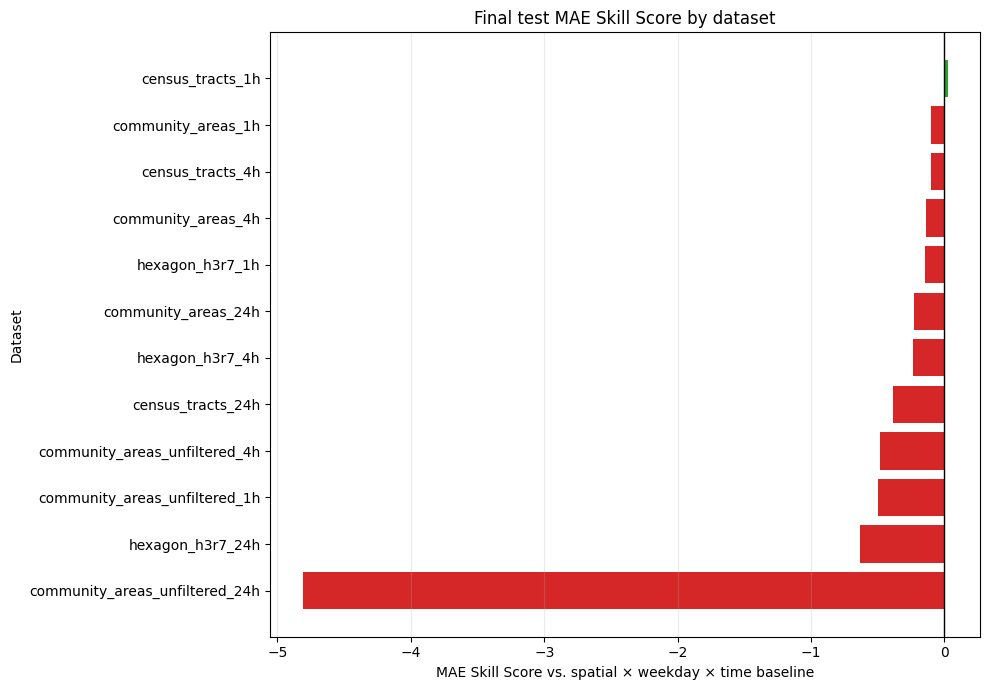

In [9]:
# Reconstruct the comparison from every saved checkpoint/prediction pair,
# independently of the subset that was active in the most recent run.
final_test_results_df = collect_all_saved_final_results()

headline_results = final_test_results_df.select(
    "model_tag", "best_epoch", "best_val_balanced_mae",
    "nn_test_mae", "spatial_time_weekday_mean_test_mae",
    "nn_test_mae_skill_score", "nn_test_balanced_mae",
    "nn_test_zero_mae", "nn_test_nonzero_mae",
    "test_demand_precision", "test_demand_recall",
).sort("nn_test_mae_skill_score", descending=True)
print(headline_results)

plot_df = final_test_results_df.sort("nn_test_mae_skill_score")
colors = [
    "tab:green" if value > 0 else "tab:red"
    for value in plot_df["nn_test_mae_skill_score"].to_list()
]
figure, axis = plt.subplots(figsize=(10, 7))
axis.barh(plot_df["model_tag"], plot_df["nn_test_mae_skill_score"], color=colors)
axis.axvline(0.0, color="black", linewidth=1)
axis.set(
    title="Final test MAE Skill Score by dataset",
    xlabel="MAE Skill Score vs. spatial × weekday × time baseline",
    ylabel="Dataset",
)
axis.grid(axis="x", alpha=0.25)
figure.tight_layout()
plt.show()

## Final training histories

The plots use Validation Balanced MAE, which is the actual checkpoint and early-stopping metric.

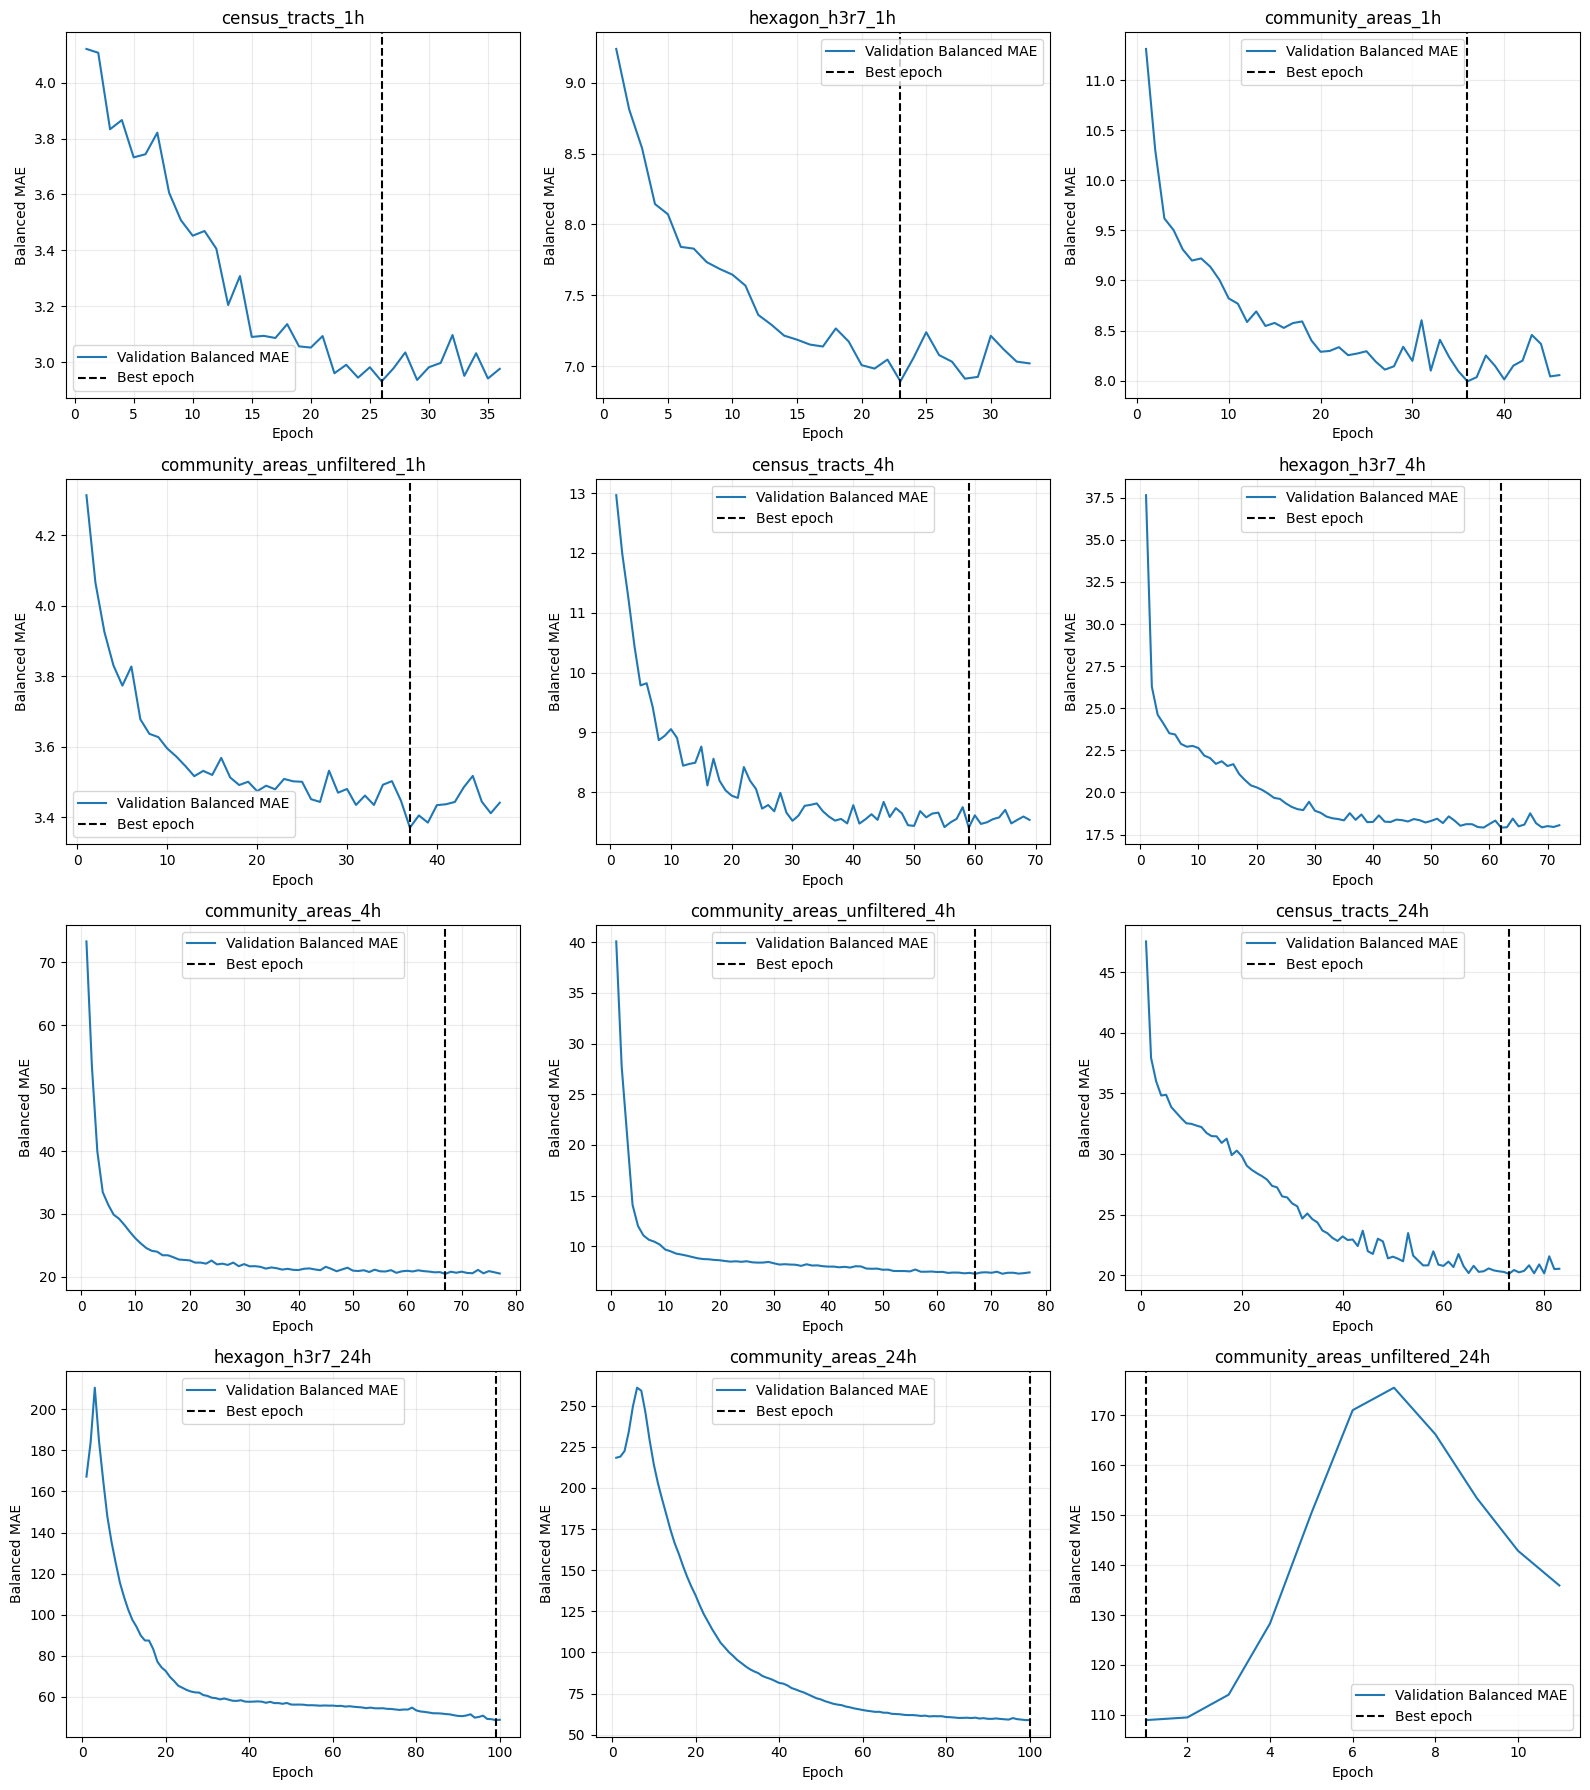

In [10]:
figure, axes = plt.subplots(4, 3, figsize=(16, 18))
for axis, config in zip(axes.flat, ALL_DATASET_CONFIGS):
    model_tag = model_tag_for(config)
    history_path = OUTPUT_DIR / f"{MODEL_VERSION}_{model_tag}_training_history.parquet"
    if not history_path.exists():
        raise FileNotFoundError(f"Missing training history: {history_path}")
    history = pl.read_parquet(history_path)
    best_epoch = final_test_results_df.filter(
        pl.col("model_tag") == model_tag
    )["best_epoch"].item()
    axis.plot(history["epoch"], history["val_balanced_mae"], label="Validation Balanced MAE")
    axis.axvline(best_epoch, color="black", linestyle="--", label="Best epoch")
    axis.set(title=model_tag, xlabel="Epoch", ylabel="Balanced MAE")
    axis.grid(alpha=0.25)
    axis.legend()
figure.tight_layout()
plt.show()